# 03 - Modelamiento
## Prueba Tecnica - Cientifico de Datos Senior

---

**Objetivo:** Entrenar, comparar y optimizar modelos para estimar el costo de los equipos a partir de las materias primas.

**Flujo:**
1. Ronda 1 -- Modelos base con parametros por defecto
2. Ronda 2 -- Con y sin feature interactions
3. Ronda 3 -- Optimizacion ligera de los que valen la pena
4. Prophet
5. Analisis de residuos del modelo ganador
6. Feature importance
7. Validacion distribucional (train vs prediccion)
8. Registro del modelo final

**Nota sobre el split temporal:** Se usa un corte cronologico 80/20 (no aleatorio) porque los datos estan correlacionados en el tiempo. La validacion cruzada tambien es temporal (TimeSeriesSplit) para respetar la estructura secuencial de los datos y evitar data leakage.

## 0. Configuracion

In [1]:
!pip install mlflow xgboost prophet --quiet

In [2]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

BUCKET = 'consulting-dataknow-prueba-tecnica'
s3 = boto3.client('s3')

def leer_csv_s3(bucket, key, **kwargs):
    obj = s3.get_object(Bucket=bucket, Key=key)
    contenido = obj['Body'].read().decode('utf-8-sig')
    return pd.read_csv(StringIO(contenido), **kwargs)

def guardar_json_s3(data, bucket, key):
    s3.put_object(Bucket=bucket, Key=key, Body=json.dumps(data, default=str, ensure_ascii=False))
    print(f'Guardado en s3://{bucket}/{key}')

mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('prueba_tecnica_equipos')

print('Entorno configurado.')

Entorno configurado.


In [3]:
df = leer_csv_s3(BUCKET, 'datos_procesados/dataset_con_features.csv', parse_dates=['Date'])

print(f'Dataset: {df.shape}')
print(f'Rango: {df["Date"].min().date()} a {df["Date"].max().date()}')

Dataset: (3500, 39)
Rango: 2010-02-15 a 2023-08-31


## 0.2 Definicion de features y split temporal

In [4]:
targets = ['Price_Equipo1', 'Price_Equipo2']

features_base = ['Price_X', 'Price_Y', 'Price_Z']

features_sin_interact = ['Price_X', 'Price_Y', 'Price_Z',
                          'Return_X', 'Return_Y', 'Return_Z',
                          'MA7_X', 'MA7_Y', 'MA7_Z',
                          'MA14_X', 'MA14_Y', 'MA14_Z',
                          'MA30_X', 'MA30_Y', 'MA30_Z',
                          'Lag1_X', 'Lag1_Y', 'Lag1_Z',
                          'Lag5_X', 'Lag5_Y', 'Lag5_Z',
                          'Vol30_X', 'Vol30_Y', 'Vol30_Z',
                          'Diff_X', 'Diff_Y', 'Diff_Z',
                          'Ratio_XY', 'Ratio_XZ', 'Ratio_YZ']

features_con_interact = features_sin_interact + ['Interact_XY', 'Interact_XZ', 'Interact_YZ']

# Split temporal 80/20
split_idx = int(len(df) * 0.8)

print(f'Split temporal (cronologico, no aleatorio):')
print(f'  Train: {df.iloc[0]["Date"].date()} a {df.iloc[split_idx-1]["Date"].date()} ({split_idx} registros)')
print(f'  Test:  {df.iloc[split_idx]["Date"].date()} a {df.iloc[-1]["Date"].date()} ({len(df) - split_idx} registros)')
print(f'\n  Nota: el test cae en periodo post-COVID, lo que es un escenario exigente')
print(f'  para los modelos porque el regimen de precios cambio.')

Split temporal (cronologico, no aleatorio):
  Train: 2010-02-15 a 2020-12-15 (2800 registros)
  Test:  2020-12-16 a 2023-08-31 (700 registros)

  Nota: el test cae en periodo post-COVID, lo que es un escenario exigente
  para los modelos porque el regimen de precios cambio.


## 0.3 Funciones auxiliares

In [5]:
def evaluar_modelo(y_true, y_pred):
    return {
        'r2': round(r2_score(y_true, y_pred), 6),
        'rmse': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'mae': round(mean_absolute_error(y_true, y_pred), 4),
        'mape': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4)
    }


def entrenar_y_registrar(modelo, nombre, features, target, df_data, split_idx, ronda='R1'):
    X_train = df_data[features].iloc[:split_idx]
    X_test = df_data[features].iloc[split_idx:]
    y_train = df_data[target].iloc[:split_idx]
    y_test = df_data[target].iloc[split_idx:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    es_lineal = isinstance(modelo, (LinearRegression, Ridge, Lasso, ElasticNet))
    X_tr = X_train_scaled if es_lineal else X_train
    X_te = X_test_scaled if es_lineal else X_test
    
    modelo.fit(X_tr, y_train)
    
    y_pred_train = modelo.predict(X_tr)
    y_pred_test = modelo.predict(X_te)
    
    metricas_train = evaluar_modelo(y_train, y_pred_train)
    metricas_test = evaluar_modelo(y_test, y_pred_test)
    
    run_name = f'{ronda}_{nombre}_{target}'
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param('modelo', nombre)
        mlflow.log_param('target', target)
        mlflow.log_param('ronda', ronda)
        mlflow.log_param('n_features', len(features))
        params = modelo.get_params()
        for k, v in params.items():
            try:
                mlflow.log_param(f'hp_{k}', v)
            except:
                pass
        for k, v in metricas_train.items():
            mlflow.log_metric(f'train_{k}', v)
        for k, v in metricas_test.items():
            mlflow.log_metric(f'test_{k}', v)
        if isinstance(modelo, XGBRegressor):
            mlflow.xgboost.log_model(modelo, 'model')
        else:
            mlflow.sklearn.log_model(modelo, 'model')
    
    return {
        'modelo': nombre, 'target': target, 'ronda': ronda,
        'n_features': len(features),
        'train': metricas_train, 'test': metricas_test,
        'y_pred_test': y_pred_test, 'y_test': y_test.values,
        'modelo_obj': modelo, 'scaler': scaler if es_lineal else None,
        'features': features
    }


def tabla_resultados(resultados):
    print(f'{"Modelo":25s} {"Target":15s} {"R2 Train":>10s} {"R2 Test":>10s} {"RMSE Test":>10s} {"MAE Test":>10s} {"MAPE Test":>10s}')
    print('-' * 95)
    for r in sorted(resultados, key=lambda x: x['test']['r2'], reverse=True):
        ovf = '  << overfit' if (r['train']['r2'] - r['test']['r2']) > 0.1 else ''
        print(f'{r["modelo"]:25s} {r["target"]:15s} {r["train"]["r2"]:10.6f} {r["test"]["r2"]:10.6f} {r["test"]["rmse"]:10.4f} {r["test"]["mae"]:10.4f} {r["test"]["mape"]:10.4f}{ovf}')

print('Funciones definidas.')

Funciones definidas.


---
## 1. Ronda 1 -- Modelos base (features base: X, Y, Z)

In [6]:
modelos_r1 = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1, verbosity=0)
}

resultados_r1 = []

for target in targets:
    print(f'\n{"=" * 60}')
    print(f'  RONDA 1 - {target} (features base)')
    print(f'{"=" * 60}')
    
    for nombre, modelo in modelos_r1.items():
        resultado = entrenar_y_registrar(clone(modelo), nombre, features_base, target, df, split_idx, 'R1_base')
        resultados_r1.append(resultado)
    
    res_target = [r for r in resultados_r1 if r['target'] == target]
    tabla_resultados(res_target)


  RONDA 1 - Price_Equipo1 (features base)


2026/04/23 08:31:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:31:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:31:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:31:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
LinearRegression          Price_Equipo1     0.992721   0.991324    10.3185     8.8725     1.5098
Ridge                     Price_Equipo1     0.992721   0.991302    10.3315     8.8775     1.5102
Lasso                     Price_Equipo1     0.992569   0.991130    10.4331     8.9328     1.5166
RandomForest              Price_Equipo1     0.992354   0.694605    61.2187    37.9303     5.4546  << overfit
ElasticNet                Price_Equipo1     0.916491   0.685596    62.1151    44.1230     6.7986  << overfit
GradientBoosting          Price_Equipo1     0.993711   0.683404    62.3312    38.0709     5.4543  << overfit
XGBoost                   Price_Equipo1     0.994277   0.667196    63.9069    39.8490     5.7265  << overfit

  RONDA 1 - Price_Equipo2 (features base)


2026/04/23 08:32:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:32:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:32:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:32:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
LinearRegression          Price_Equipo2     0.986759   0.985236    19.3179    16.5660     1.5044
Ridge                     Price_Equipo2     0.986759   0.985236    19.3181    16.5624     1.5040
Lasso                     Price_Equipo2     0.986679   0.985057    19.4350    16.5646     1.5018
ElasticNet                Price_Equipo2     0.936599   0.722536    83.7459    69.1406     5.8776  << overfit
GradientBoosting          Price_Equipo2     0.988171   0.612328    98.9902    58.2735     4.6039  << overfit
XGBoost                   Price_Equipo2     0.989340   0.602658   100.2172    58.3235     4.6083  << overfit
RandomForest              Price_Equipo2     0.983824   0.600740   100.4588    62.7649     5.0578  << overfit


---
## 2. Ronda 2 -- Con y sin feature interactions

In [7]:
resultados_r2 = []

conjuntos = {
    'sin_interact': features_sin_interact,
    'con_interact': features_con_interact
}

# Tree-based con parametros conservadores para evitar overfit
modelos_r2 = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0)
}

for target in targets:
    for conj_nombre, features in conjuntos.items():
        print(f'\n{"=" * 60}')
        print(f'  RONDA 2 - {target} ({conj_nombre}, {len(features)} features)')
        print(f'{"=" * 60}')
        
        for nombre, modelo in modelos_r2.items():
            ronda_tag = f'R2_{conj_nombre}'
            resultado = entrenar_y_registrar(clone(modelo), nombre, features, target, df, split_idx, ronda_tag)
            resultados_r2.append(resultado)
        
        res_target = [r for r in resultados_r2 if r['target'] == target and r['ronda'] == f'R2_{conj_nombre}']
        tabla_resultados(res_target)

2026/04/23 08:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:32:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  RONDA 2 - Price_Equipo1 (sin_interact, 30 features)


2026/04/23 08:32:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:32:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:32:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:32:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
Lasso                     Price_Equipo1     0.992571   0.991146    10.4240     8.9268     1.5158
Ridge                     Price_Equipo1     0.992747   0.990890    10.5731     8.9405     1.5161
ElasticNet                Price_Equipo1     0.984494   0.932349    28.8131    21.2380     3.3979
RandomForest              Price_Equipo1     0.992547   0.686568    62.0190    38.7818     5.5835  << overfit
XGBoost                   Price_Equipo1     0.993250   0.642509    66.2347    40.8767     5.8524  << overfit
GradientBoosting          Price_Equipo1     0.993431   0.638182    66.6343    40.8954     5.8510  << overfit

  RONDA 2 - Price_Equipo1 (con_interact, 33 features)


2026/04/23 08:33:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:33:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:33:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:33:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
Lasso                     Price_Equipo1     0.992537   0.991157    10.4171     8.9340     1.5179
Ridge                     Price_Equipo1     0.992746   0.990806    10.6218     8.9859     1.5252
ElasticNet                Price_Equipo1     0.985396   0.941485    26.7971    19.9613     3.1999
RandomForest              Price_Equipo1     0.992626   0.686080    62.0672    38.8707     5.5987  << overfit
GradientBoosting          Price_Equipo1     0.993508   0.656252    64.9491    40.5189     5.8101  << overfit
XGBoost                   Price_Equipo1     0.993302   0.635368    66.8929    41.8725     6.0012  << overfit

  RONDA 2 - Price_Equipo2 (sin_interact, 30 features)


2026/04/23 08:33:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:33:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:33:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:33:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
Lasso                     Price_Equipo2     0.986677   0.985074    19.4239    16.5539     1.5010
Ridge                     Price_Equipo2     0.986847   0.984688    19.6729    16.8003     1.5228
ElasticNet                Price_Equipo2     0.977724   0.954536    33.8995    25.6135     2.2154
RandomForest              Price_Equipo2     0.984590   0.596629   100.9747    62.8854     5.0683  << overfit
GradientBoosting          Price_Equipo2     0.987703   0.590469   101.7428    61.3928     4.8734  << overfit
XGBoost                   Price_Equipo2     0.987316   0.580671   102.9527    61.9555     4.9119  << overfit

  RONDA 2 - Price_Equipo2 (con_interact, 33 features)


2026/04/23 08:34:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:34:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 08:34:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:34:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
Lasso                     Price_Equipo2     0.986625   0.984999    19.4724    16.5994     1.5046
Ridge                     Price_Equipo2     0.986853   0.984125    20.0316    16.9878     1.5398
ElasticNet                Price_Equipo2     0.978929   0.964786    29.8342    23.1403     2.0331
RandomForest              Price_Equipo2     0.984591   0.611991    99.0333    59.4151     4.7363  << overfit
GradientBoosting          Price_Equipo2     0.988023   0.593332   101.3865    59.3932     4.6781  << overfit
XGBoost                   Price_Equipo2     0.987491   0.584057   102.5361    60.5302     4.7746  << overfit


In [8]:
# Comparacion consolidada R1 vs R2
print('\nCOMPARACION CONSOLIDADA - TOP 10 POR TARGET')
print('=' * 110)

todos = resultados_r1 + resultados_r2

for target in targets:
    print(f'\n--- {target} ---')
    print(f'{"Ronda":20s} {"Modelo":25s} {"R2 Train":>10s} {"R2 Test":>10s} {"RMSE Test":>10s} {"MAPE Test":>10s} {"Overfit?":>10s}')
    print('-' * 100)
    res_target = sorted([r for r in todos if r['target'] == target], key=lambda x: x['test']['r2'], reverse=True)
    for r in res_target[:10]:
        gap = r['train']['r2'] - r['test']['r2']
        ovf = 'SI' if gap > 0.1 else 'no'
        print(f'{r["ronda"]:20s} {r["modelo"]:25s} {r["train"]["r2"]:10.6f} {r["test"]["r2"]:10.6f} {r["test"]["rmse"]:10.4f} {r["test"]["mape"]:10.4f} {ovf:>10s}')


COMPARACION CONSOLIDADA - TOP 10 POR TARGET

--- Price_Equipo1 ---
Ronda                Modelo                      R2 Train    R2 Test  RMSE Test  MAPE Test   Overfit?
----------------------------------------------------------------------------------------------------
R1_base              LinearRegression            0.992721   0.991324    10.3185     1.5098         no
R1_base              Ridge                       0.992721   0.991302    10.3315     1.5102         no
R2_con_interact      Lasso                       0.992537   0.991157    10.4171     1.5179         no
R2_sin_interact      Lasso                       0.992571   0.991146    10.4240     1.5158         no
R1_base              Lasso                       0.992569   0.991130    10.4331     1.5166         no
R2_sin_interact      Ridge                       0.992747   0.990890    10.5731     1.5161         no
R2_con_interact      Ridge                       0.992746   0.990806    10.6218     1.5252         no
R2_con_interact

---
## 3. Ronda 3 -- Optimizacion ligera

Solo se optimizan los modelos lineales que son los que generalizan bien. Los tree-based se dejan con parametros conservadores porque mostraron sobreajuste consistente en las rondas anteriores.

In [9]:
resultados_r3 = []
tscv = TimeSeriesSplit(n_splits=5)
mejores_modelos = {}

# Grids ligeros - solo modelos lineales que valen la pena
param_grids = {
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
    },
    'ElasticNet': {
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }
}

# Tree-based con un solo ajuste conservador (sin grid search)
tree_configs = {
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=5, min_samples_leaf=10, 
        min_samples_split=20, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        subsample=0.9, random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.8, random_state=42, 
        n_jobs=-1, verbosity=0)
}

for target in targets:
    print(f'\n{"=" * 60}')
    print(f'  RONDA 3 - OPTIMIZACION - {target}')
    print(f'{"=" * 60}')
    
    features = features_con_interact
    X_train = df[features].iloc[:split_idx]
    X_test = df[features].iloc[split_idx:]
    y_train = df[target].iloc[:split_idx]
    y_test = df[target].iloc[split_idx:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    mejor_r2 = -999
    
    # --- Modelos lineales con GridSearchCV ---
    modelos_lineales = {
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'ElasticNet': ElasticNet()
    }
    
    for nombre, modelo in modelos_lineales.items():
        print(f'\n  Optimizando {nombre}...')
        
        search = GridSearchCV(modelo, param_grids[nombre], cv=tscv, scoring='r2', n_jobs=-1)
        search.fit(X_train_scaled, y_train)
        
        y_pred_train = search.predict(X_train_scaled)
        y_pred_test = search.predict(X_test_scaled)
        
        metricas_train = evaluar_modelo(y_train, y_pred_train)
        metricas_test = evaluar_modelo(y_test, y_pred_test)
        
        print(f'    Mejores params: {search.best_params_}')
        print(f'    R2 CV: {search.best_score_:.6f}')
        print(f'    R2 Test: {metricas_test["r2"]:.6f}, RMSE: {metricas_test["rmse"]:.4f}')
        
        with mlflow.start_run(run_name=f'R3_opt_{nombre}_{target}'):
            mlflow.log_param('modelo', nombre)
            mlflow.log_param('target', target)
            mlflow.log_param('ronda', 'R3_optimizado')
            mlflow.log_param('n_features', len(features))
            mlflow.log_param('cv_best_score', round(search.best_score_, 6))
            for k, v in search.best_params_.items():
                mlflow.log_param(f'hp_{k}', v)
            for k, v in metricas_train.items():
                mlflow.log_metric(f'train_{k}', v)
            for k, v in metricas_test.items():
                mlflow.log_metric(f'test_{k}', v)
            mlflow.sklearn.log_model(search.best_estimator_, 'model')
        
        resultado = {
            'modelo': nombre, 'target': target, 'ronda': 'R3_optimizado',
            'n_features': len(features), 'best_params': search.best_params_,
            'cv_best_score': round(search.best_score_, 6),
            'train': metricas_train, 'test': metricas_test,
            'y_pred_test': y_pred_test, 'y_test': y_test.values,
            'modelo_obj': search.best_estimator_, 'scaler': scaler,
            'features': features
        }
        resultados_r3.append(resultado)
        
        if metricas_test['r2'] > mejor_r2:
            mejor_r2 = metricas_test['r2']
            mejores_modelos[target] = resultado
    
    # --- Tree-based con config conservadora (sin grid search) ---
    for nombre, modelo in tree_configs.items():
        print(f'\n  {nombre} (config conservadora, sin grid search)...')
        
        modelo_c = clone(modelo)
        modelo_c.fit(X_train, y_train)
        
        y_pred_train = modelo_c.predict(X_train)
        y_pred_test = modelo_c.predict(X_test)
        
        metricas_train = evaluar_modelo(y_train, y_pred_train)
        metricas_test = evaluar_modelo(y_test, y_pred_test)
        
        gap = metricas_train['r2'] - metricas_test['r2']
        print(f'    R2 Train: {metricas_train["r2"]:.6f}, R2 Test: {metricas_test["r2"]:.6f}, Gap: {gap:.4f}')
        
        with mlflow.start_run(run_name=f'R3_conserv_{nombre}_{target}'):
            mlflow.log_param('modelo', nombre)
            mlflow.log_param('target', target)
            mlflow.log_param('ronda', 'R3_conservador')
            mlflow.log_param('n_features', len(features))
            for k, v in modelo_c.get_params().items():
                try:
                    mlflow.log_param(f'hp_{k}', v)
                except:
                    pass
            for k, v in metricas_train.items():
                mlflow.log_metric(f'train_{k}', v)
            for k, v in metricas_test.items():
                mlflow.log_metric(f'test_{k}', v)
            if isinstance(modelo_c, XGBRegressor):
                mlflow.xgboost.log_model(modelo_c, 'model')
            else:
                mlflow.sklearn.log_model(modelo_c, 'model')
        
        resultado = {
            'modelo': nombre, 'target': target, 'ronda': 'R3_conservador',
            'n_features': len(features),
            'train': metricas_train, 'test': metricas_test,
            'y_pred_test': y_pred_test, 'y_test': y_test.values,
            'modelo_obj': modelo_c, 'scaler': None, 'features': features
        }
        resultados_r3.append(resultado)
        
        if metricas_test['r2'] > mejor_r2:
            mejor_r2 = metricas_test['r2']
            mejores_modelos[target] = resultado
    
    print(f'\n  >> Mejor modelo para {target}: {mejores_modelos[target]["modelo"]} (R2={mejor_r2:.6f})')


  RONDA 3 - OPTIMIZACION - Price_Equipo1

  Optimizando Ridge...


2026/04/23 08:34:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:34:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    Mejores params: {'alpha': 0.1}
    R2 CV: 0.967115
    R2 Test: 0.991304, RMSE: 10.3302

  Optimizando Lasso...


2026/04/23 08:34:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:34:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    Mejores params: {'alpha': 0.1}
    R2 CV: 0.970436
    R2 Test: 0.991341, RMSE: 10.3081

  Optimizando ElasticNet...


...

    R2 Train: 0.984648, R2 Test: 0.608613, Gap: 0.3760

  GradientBoosting (config conservadora, sin grid search)...


2026/04/23 08:36:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 08:36:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    R2 Train: 0.988757, R2 Test: 0.637492, Gap: 0.3513

  XGBoost (config conservadora, sin grid search)...


2026/04/23 08:36:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


    R2 Train: 0.988218, R2 Test: 0.598173, Gap: 0.3900

  >> Mejor modelo para Price_Equipo2: Lasso (R2=0.985174)


In [10]:
print('\nRESULTADOS RONDA 3')
print('=' * 110)
for target in targets:
    print(f'\n--- {target} ---')
    res_target = sorted([r for r in resultados_r3 if r['target'] == target], key=lambda x: x['test']['r2'], reverse=True)
    tabla_resultados(res_target)


RESULTADOS RONDA 3

--- Price_Equipo1 ---
Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
-----------------------------------------------------------------------------------------------
Lasso                     Price_Equipo1     0.992725   0.991341    10.3081     8.8641     1.5084
Ridge                     Price_Equipo1     0.992776   0.991304    10.3302     8.8337     1.5045
ElasticNet                Price_Equipo1     0.992751   0.991022    10.4965     8.9200     1.5186
RandomForest              Price_Equipo1     0.992637   0.687184    61.9581    38.8123     5.5909  << overfit
GradientBoosting          Price_Equipo1     0.994004   0.667800    63.8488    39.8196     5.7171  << overfit
XGBoost                   Price_Equipo1     0.993756   0.655090    65.0588    40.6991     5.8391  << overfit

--- Price_Equipo2 ---
Modelo                    Target            R2 Train    R2 Test  RMSE Test   MAE Test  MAPE Test
--------------------------

---
## 4. Prophet

In [ ]:
from prophet import Prophet

resultados_prophet = {}
forecast_completo = {}

for target in targets:
    print(f'\n{"=" * 60}')
    print(f'  PROPHET - {target}')
    print(f'{"=" * 60}')
    
    df_prophet = df[['Date', target, 'Price_X', 'Price_Y', 'Price_Z']].copy()
    df_prophet = df_prophet.rename(columns={'Date': 'ds', target: 'y'})
    
    train_prophet = df_prophet.iloc[:split_idx]
    test_prophet = df_prophet.iloc[split_idx:]
    
    modelo_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )
    
    modelo_prophet.add_regressor('Price_X')
    modelo_prophet.add_regressor('Price_Y')
    modelo_prophet.add_regressor('Price_Z')
    
    modelo_prophet.fit(train_prophet)
    
    # Forecast sobre train y test completo
    forecast_all = modelo_prophet.predict(df_prophet)
    forecast_test = modelo_prophet.predict(test_prophet)
    forecast_train = modelo_prophet.predict(train_prophet)
    
    y_pred_prophet = forecast_test['yhat'].values
    y_test_prophet = test_prophet['y'].values
    
    metricas_prophet = evaluar_modelo(y_test_prophet, y_pred_prophet)
    metricas_prophet_train = evaluar_modelo(train_prophet['y'].values, forecast_train['yhat'].values)
    
    print(f'  Train - R2: {metricas_prophet_train["r2"]:.6f}, RMSE: {metricas_prophet_train["rmse"]:.4f}')
    print(f'  Test  - R2: {metricas_prophet["r2"]:.6f}, RMSE: {metricas_prophet["rmse"]:.4f}, MAE: {metricas_prophet["mae"]:.4f}, MAPE: {metricas_prophet["mape"]:.4f}')
    print(f'  Changepoints detectados: {len(modelo_prophet.changepoints)}')
    print(f'  Intervalo de confianza: 95%')
    print(f'  Ancho promedio del intervalo (test): {(forecast_test["yhat_upper"] - forecast_test["yhat_lower"]).mean():.2f}')
    
    with mlflow.start_run(run_name=f'Prophet_{target}'):
        mlflow.log_param('modelo', 'Prophet')
        mlflow.log_param('target', target)
        mlflow.log_param('ronda', 'Prophet')
        mlflow.log_param('regressors', 'Price_X, Price_Y, Price_Z')
        mlflow.log_param('changepoint_prior_scale', 0.05)
        mlflow.log_param('interval_width', 0.95)
        mlflow.log_param('n_changepoints', len(modelo_prophet.changepoints))
        for k, v in metricas_prophet_train.items():
            mlflow.log_metric(f'train_{k}', v)
        for k, v in metricas_prophet.items():
            mlflow.log_metric(f'test_{k}', v)
    
    resultados_prophet[target] = {
        'train': metricas_prophet_train, 'test': metricas_prophet,
        'n_changepoints': len(modelo_prophet.changepoints),
        'changepoints': [str(cp.date()) for cp in modelo_prophet.changepoints],
        'modelo_obj': modelo_prophet,
        'forecast_test': forecast_test,
        'forecast_train': forecast_train,
        'forecast_all': forecast_all,
        'y_pred_test': y_pred_prophet, 'y_test': y_test_prophet,
        'train_data': train_prophet, 'test_data': test_prophet
    }
    forecast_completo[target] = forecast_all

### 4.1 Visualizacion Prophet: Train + Test + Intervalos de Confianza

In [ ]:
# Grafica Prophet: ajuste en train + prediccion en test + intervalos de confianza
for target in targets:
    rp = resultados_prophet[target]
    forecast_all = rp['forecast_all']
    train_data = rp['train_data']
    test_data = rp['test_data']
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # --- Panel 1: Serie completa con ajuste y prediccion ---
    ax = axes[0]
    
    # Datos reales
    ax.plot(train_data['ds'], train_data['y'], linewidth=0.6, color='steelblue', label='Train (real)', alpha=0.7)
    ax.plot(test_data['ds'], test_data['y'], linewidth=1.2, color='green', label='Test (real)')
    
    # Prediccion Prophet
    ax.plot(forecast_all['ds'], forecast_all['yhat'], linewidth=1, color='darkorange', label='Prophet (prediccion)', alpha=0.8)
    
    # Intervalos de confianza
    ax.fill_between(forecast_all['ds'], forecast_all['yhat_lower'], forecast_all['yhat_upper'],
                     alpha=0.15, color='darkorange', label='IC 95%')
    
    # Linea de corte train/test
    ax.axvline(x=df.iloc[split_idx]['Date'], color='red', linestyle='--', linewidth=1, label='Corte train/test')
    
    ax.set_title(f'Prophet - {target}: Ajuste en Train + Prediccion en Test', fontweight='bold', fontsize=13)
    ax.set_ylabel('Precio')
    ax.legend(loc='upper left', fontsize=9)
    
    # --- Panel 2: Zoom en test ---
    ax2 = axes[1]
    
    forecast_test = rp['forecast_test']
    
    ax2.plot(test_data['ds'], test_data['y'], linewidth=1.5, color='green', label='Test (real)')
    ax2.plot(forecast_test['ds'], forecast_test['yhat'], linewidth=1.5, color='darkorange', label='Prophet (prediccion)')
    ax2.fill_between(forecast_test['ds'], forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                      alpha=0.2, color='darkorange', label='IC 95%')
    
    ax2.set_title(f'Prophet - {target}: Zoom en Periodo de Test', fontweight='bold', fontsize=13)
    ax2.set_ylabel('Precio')
    ax2.set_xlabel('Fecha')
    ax2.legend(loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Cobertura del intervalo de confianza
    dentro_ic = ((test_data['y'].values >= forecast_test['yhat_lower'].values) & 
                 (test_data['y'].values <= forecast_test['yhat_upper'].values)).mean() * 100
    print(f'{target}:')
    print(f'  Cobertura del IC 95%: {dentro_ic:.1f}% de los datos de test caen dentro del intervalo')
    print(f'  Ancho promedio IC: {(forecast_test["yhat_upper"] - forecast_test["yhat_lower"]).mean():.2f}')
    print()

### 4.2 Componentes de Prophet

In [ ]:
# Componentes de Prophet
for target in targets:
    rp = resultados_prophet[target]
    modelo_prophet = rp['modelo_obj']
    forecast_test = rp['forecast_test']
    
    fig = modelo_prophet.plot_components(forecast_test)
    fig.suptitle(f'Componentes Prophet - {target}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 4.3 Analisis de Residuales de Prophet

In [ ]:
# Residuales de Prophet
from statsmodels.stats.diagnostic import acorr_ljungbox as acorr_lb_prophet

prophet_residuos_resultados = {}

for target in targets:
    rp = resultados_prophet[target]
    residuos_p = rp['y_test'] - rp['y_pred_test']
    
    print(f'\n{"=" * 60}')
    print(f'  RESIDUALES PROPHET - {target}')
    print(f'{"=" * 60}')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Analisis de Residuos Prophet - {target}', fontsize=14, fontweight='bold')
    
    # Residuos vs prediccion
    axes[0, 0].scatter(rp['y_pred_test'], residuos_p, alpha=0.3, s=10, color='darkorange')
    axes[0, 0].axhline(y=0, color='red', linewidth=1)
    axes[0, 0].set_xlabel('Prediccion')
    axes[0, 0].set_ylabel('Residuo')
    axes[0, 0].set_title('Residuos vs Prediccion')
    
    # Histograma
    axes[0, 1].hist(residuos_p, bins=40, color='darkorange', edgecolor='white', alpha=0.8, density=True)
    x_norm = np.linspace(residuos_p.min(), residuos_p.max(), 100)
    axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuos_p.mean(), residuos_p.std()), 'r-', linewidth=2)
    axes[0, 1].set_title('Distribucion de Residuos')
    
    # QQ plot
    stats.probplot(residuos_p, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('QQ Plot')
    
    # Residuos en el tiempo
    fechas_test = df['Date'].iloc[split_idx:].values
    axes[1, 1].plot(fechas_test, residuos_p, linewidth=0.5, color='darkorange')
    axes[1, 1].axhline(y=0, color='red', linewidth=1)
    axes[1, 1].set_title('Residuos en el Tiempo')
    
    plt.tight_layout()
    plt.show()
    
    # Tests
    sw_stat, sw_p = stats.shapiro(residuos_p[:5000])
    jb_stat, jb_p = stats.jarque_bera(residuos_p)
    lb_result = acorr_lb_prophet(residuos_p, lags=[10], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    
    print(f'  Media residuos: {residuos_p.mean():.4f}')
    print(f'  Std residuos: {residuos_p.std():.4f}')
    print(f'  Shapiro-Wilk p-value: {sw_p:.6f} ({"Normal" if sw_p > 0.05 else "No normal"})')
    print(f'  Jarque-Bera p-value: {jb_p:.6f} ({"Normal" if jb_p > 0.05 else "No normal"})')
    print(f'  Ljung-Box p-value (lag=10): {lb_p:.6f} ({"No autocorrelacion" if lb_p > 0.05 else "Hay autocorrelacion"})')
    
    prophet_residuos_resultados[target] = {
        'media': round(float(residuos_p.mean()), 4),
        'std': round(float(residuos_p.std()), 4),
        'shapiro_p': round(sw_p, 6),
        'jarque_bera_p': round(jb_p, 6),
        'ljung_box_p': round(lb_p, 6)
    }

### 4.4 Comparacion Visual: Lasso vs Prophet

In [ ]:
# Comparacion visual: Lasso vs Prophet en test
for target in targets:
    mejor = mejores_modelos[target]
    rp = resultados_prophet[target]
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    fechas_test = df['Date'].iloc[split_idx:].values
    y_real = mejor['y_test']
    
    # Panel 1: ambos modelos vs real
    axes[0].plot(fechas_test, y_real, linewidth=1.5, color='steelblue', label='Real')
    axes[0].plot(fechas_test, mejor['y_pred_test'], linewidth=1, color='red', label=f'Lasso (R2={mejor["test"]["r2"]:.4f})', alpha=0.8)
    axes[0].plot(fechas_test, rp['y_pred_test'], linewidth=1, color='darkorange', label=f'Prophet (R2={rp["test"]["r2"]:.4f})', alpha=0.8)
    axes[0].set_title(f'{target}: Lasso vs Prophet vs Real', fontweight='bold', fontsize=13)
    axes[0].set_ylabel('Precio')
    axes[0].legend(fontsize=10)
    
    # Panel 2: Prophet con intervalos
    forecast_test = rp['forecast_test']
    axes[1].plot(fechas_test, y_real, linewidth=1.5, color='steelblue', label='Real')
    axes[1].plot(forecast_test['ds'].values, forecast_test['yhat'].values, linewidth=1, color='darkorange', label='Prophet')
    axes[1].fill_between(forecast_test['ds'].values, 
                          forecast_test['yhat_lower'].values, 
                          forecast_test['yhat_upper'].values,
                          alpha=0.2, color='darkorange', label='IC 95%')
    axes[1].set_title(f'{target}: Prophet con Intervalos de Confianza', fontweight='bold', fontsize=13)
    axes[1].set_ylabel('Precio')
    axes[1].set_xlabel('Fecha')
    axes[1].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

---
## 5. Comparacion final de todos los modelos

In [12]:
comparacion_final = {}

for target in targets:
    print(f'\n{"=" * 80}')
    print(f'  COMPARACION FINAL - {target}')
    print(f'{"=" * 80}')
    print(f'{"Ronda":20s} {"Modelo":25s} {"R2 Train":>10s} {"R2 Test":>10s} {"RMSE Test":>10s} {"MAPE Test":>10s} {"Gap":>8s}')
    print('-' * 100)
    
    filas = []
    for r in resultados_r1 + resultados_r2 + resultados_r3:
        if r['target'] == target:
            filas.append(r)
    
    filas.append({
        'ronda': 'Prophet', 'modelo': 'Prophet',
        'train': resultados_prophet[target]['train'],
        'test': resultados_prophet[target]['test']
    })
    
    filas_sorted = sorted(filas, key=lambda x: x['test']['r2'], reverse=True)
    
    comp_target = []
    for r in filas_sorted[:15]:
        gap = r['train']['r2'] - r['test']['r2']
        print(f'{r["ronda"]:20s} {r["modelo"]:25s} {r["train"]["r2"]:10.6f} {r["test"]["r2"]:10.6f} {r["test"]["rmse"]:10.4f} {r["test"]["mape"]:10.4f} {gap:8.4f}')
        comp_target.append({
            'ronda': r['ronda'], 'modelo': r['modelo'],
            'train_r2': r['train']['r2'], 'test_r2': r['test']['r2'],
            'test_rmse': r['test']['rmse'], 'test_mae': r['test']['mae'],
            'test_mape': r['test']['mape'], 'gap': round(gap, 4)
        })
    
    comparacion_final[target] = comp_target

guardar_json_s3(comparacion_final, BUCKET, 'eda_resultados/comparacion_modelos.json')


  COMPARACION FINAL - Price_Equipo1
Ronda                Modelo                      R2 Train    R2 Test  RMSE Test  MAPE Test      Gap
----------------------------------------------------------------------------------------------------
R3_optimizado        Lasso                       0.992725   0.991341    10.3081     1.5084   0.0014
R1_base              LinearRegression            0.992721   0.991324    10.3185     1.5098   0.0014
R3_optimizado        Ridge                       0.992776   0.991304    10.3302     1.5045   0.0015
R1_base              Ridge                       0.992721   0.991302    10.3315     1.5102   0.0014
R2_con_interact      Lasso                       0.992537   0.991157    10.4171     1.5179   0.0014
R2_sin_interact      Lasso                       0.992571   0.991146    10.4240     1.5158   0.0014
R1_base              Lasso                       0.992569   0.991130    10.4331     1.5166   0.0014
Prophet              Prophet                     0.992784   0.

---
## 6. Analisis de residuos del modelo ganador


  ANALISIS DE RESIDUOS - Price_Equipo1


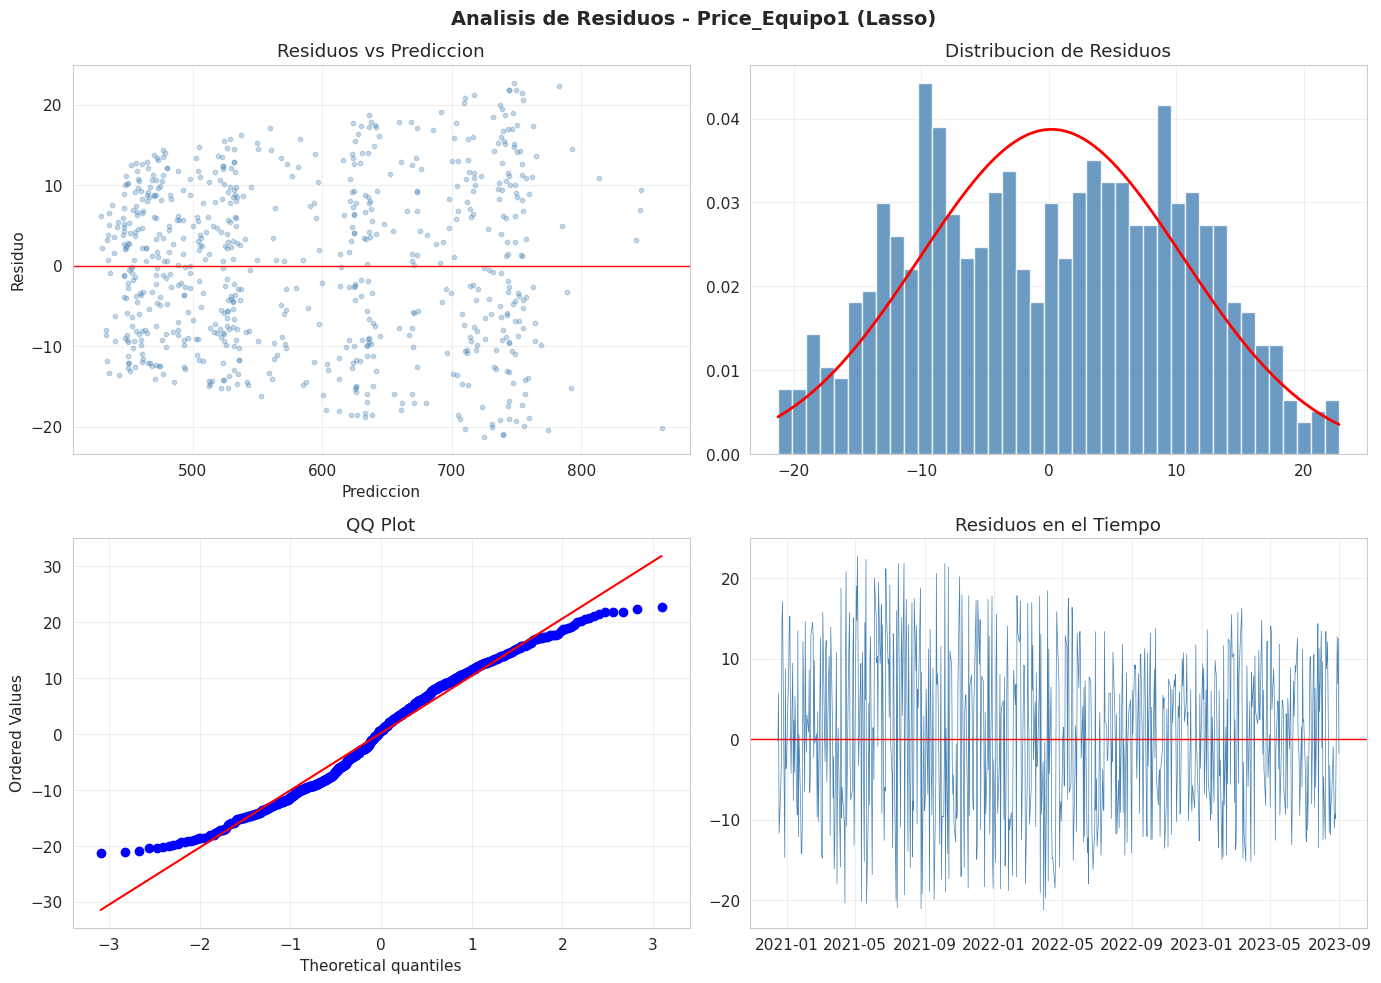

  Modelo: Lasso
  Media residuos: 0.2182
  Std residuos: 10.3058
  Shapiro-Wilk p-value: 0.000000 (No normal)
  Jarque-Bera p-value: 0.000001 (No normal)
  Ljung-Box p-value (lag=10): 0.888867 (No autocorrelacion)

  ANALISIS DE RESIDUOS - Price_Equipo2


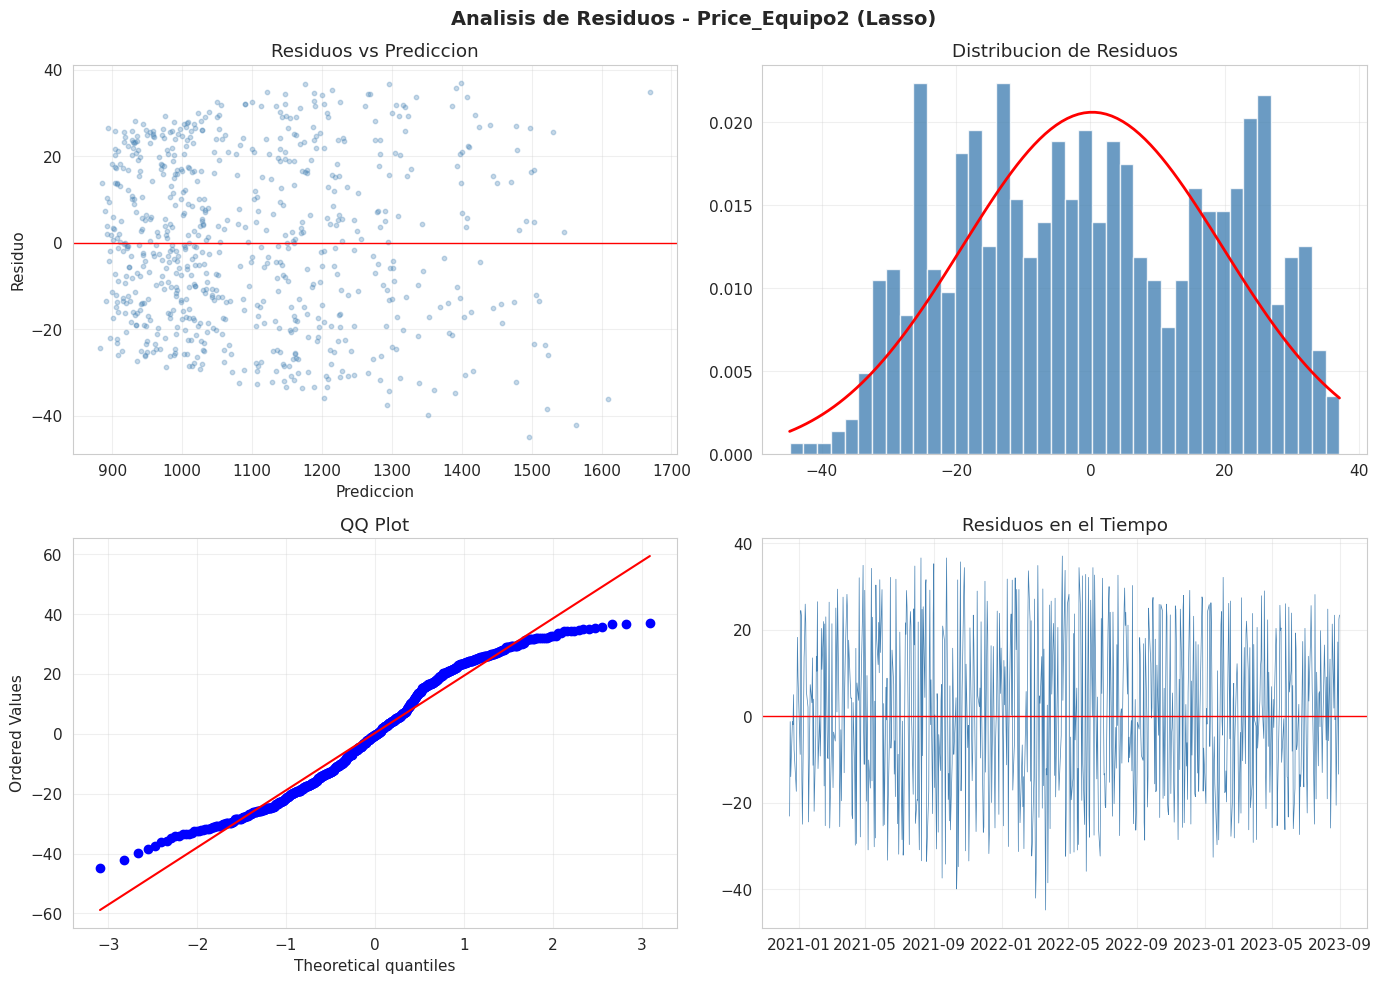

  Modelo: Lasso
  Media residuos: 0.2668
  Std residuos: 19.3564
  Shapiro-Wilk p-value: 0.000000 (No normal)
  Jarque-Bera p-value: 0.000000 (No normal)
  Ljung-Box p-value (lag=10): 0.138723 (No autocorrelacion)
Guardado en s3://consulting-dataknow-prueba-tecnica/eda_resultados/analisis_residuos.json


In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos_resultados = {}

for target in targets:
    print(f'\n{"=" * 60}')
    print(f'  ANALISIS DE RESIDUOS - {target}')
    print(f'{"=" * 60}')
    
    mejor = mejores_modelos[target]
    residuos = mejor['y_test'] - mejor['y_pred_test']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Analisis de Residuos - {target} ({mejor["modelo"]})', fontsize=14, fontweight='bold')
    
    axes[0, 0].scatter(mejor['y_pred_test'], residuos, alpha=0.3, s=10, color='steelblue')
    axes[0, 0].axhline(y=0, color='red', linewidth=1)
    axes[0, 0].set_xlabel('Prediccion')
    axes[0, 0].set_ylabel('Residuo')
    axes[0, 0].set_title('Residuos vs Prediccion')
    
    axes[0, 1].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    x_norm = np.linspace(residuos.min(), residuos.max(), 100)
    axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()), 'r-', linewidth=2)
    axes[0, 1].set_title('Distribucion de Residuos')
    
    stats.probplot(residuos, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('QQ Plot')
    
    fechas_test = df['Date'].iloc[split_idx:].values
    axes[1, 1].plot(fechas_test, residuos, linewidth=0.5, color='steelblue')
    axes[1, 1].axhline(y=0, color='red', linewidth=1)
    axes[1, 1].set_title('Residuos en el Tiempo')
    
    plt.tight_layout()
    plt.show()
    
    sw_stat, sw_p = stats.shapiro(residuos[:5000])
    jb_stat, jb_p = stats.jarque_bera(residuos)
    lb_result = acorr_ljungbox(residuos, lags=[10], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    
    print(f'  Modelo: {mejor["modelo"]}')
    print(f'  Media residuos: {residuos.mean():.4f}')
    print(f'  Std residuos: {residuos.std():.4f}')
    print(f'  Shapiro-Wilk p-value: {sw_p:.6f} ({"Normal" if sw_p > 0.05 else "No normal"})')
    print(f'  Jarque-Bera p-value: {jb_p:.6f} ({"Normal" if jb_p > 0.05 else "No normal"})')
    print(f'  Ljung-Box p-value (lag=10): {lb_p:.6f} ({"No autocorrelacion" if lb_p > 0.05 else "Hay autocorrelacion"})')
    
    residuos_resultados[target] = {
        'modelo': mejor['modelo'],
        'media': round(float(residuos.mean()), 4),
        'std': round(float(residuos.std()), 4),
        'shapiro_p': round(sw_p, 6),
        'jarque_bera_p': round(jb_p, 6),
        'ljung_box_p': round(lb_p, 6)
    }

guardar_json_s3(residuos_resultados, BUCKET, 'eda_resultados/analisis_residuos.json')

---
## 7. Feature Importance


  FEATURE IMPORTANCE - Price_Equipo1 (Lasso)


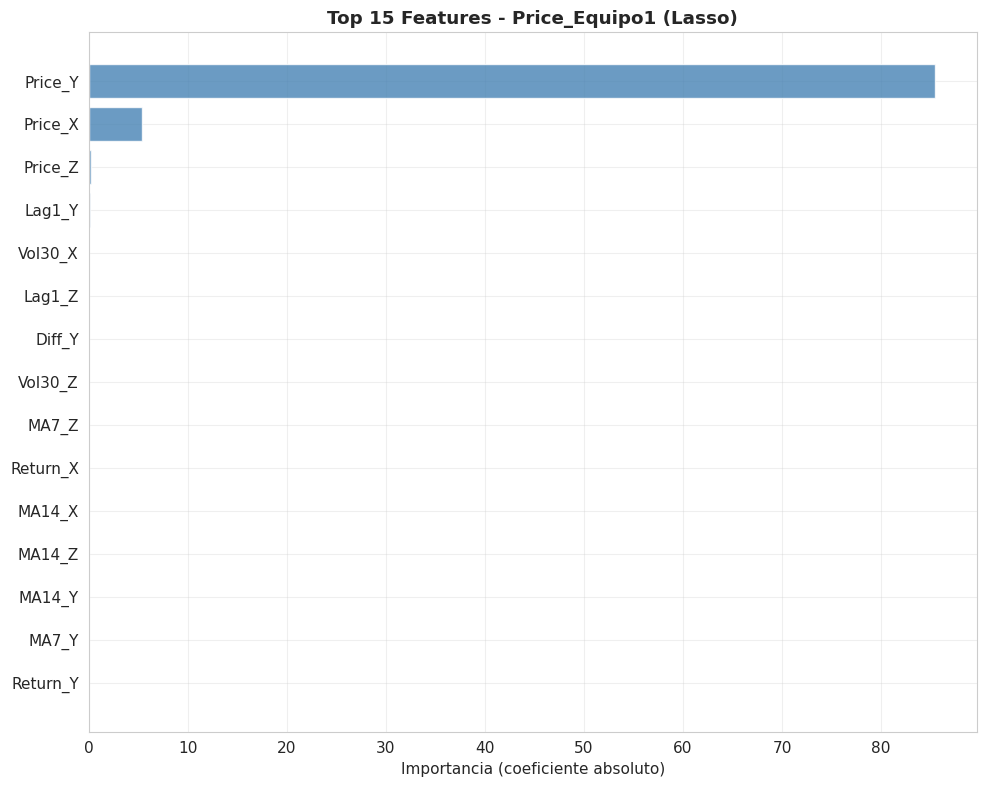

  Price_Y                  : 85.411843
  Price_X                  : 5.387346
  Price_Z                  : 0.204188
  Lag1_Y                   : 0.149895
  Vol30_X                  : 0.075025
  Lag1_Z                   : 0.074377
  Diff_Y                   : 0.070741
  Vol30_Z                  : 0.047131
  MA7_Z                    : 0.011740
  Return_X                 : 0.006809
  MA14_X                   : 0.000000
  MA14_Z                   : 0.000000
  MA14_Y                   : 0.000000
  MA7_Y                    : 0.000000
  Return_Y                 : 0.000000

  FEATURE IMPORTANCE - Price_Equipo2 (Lasso)


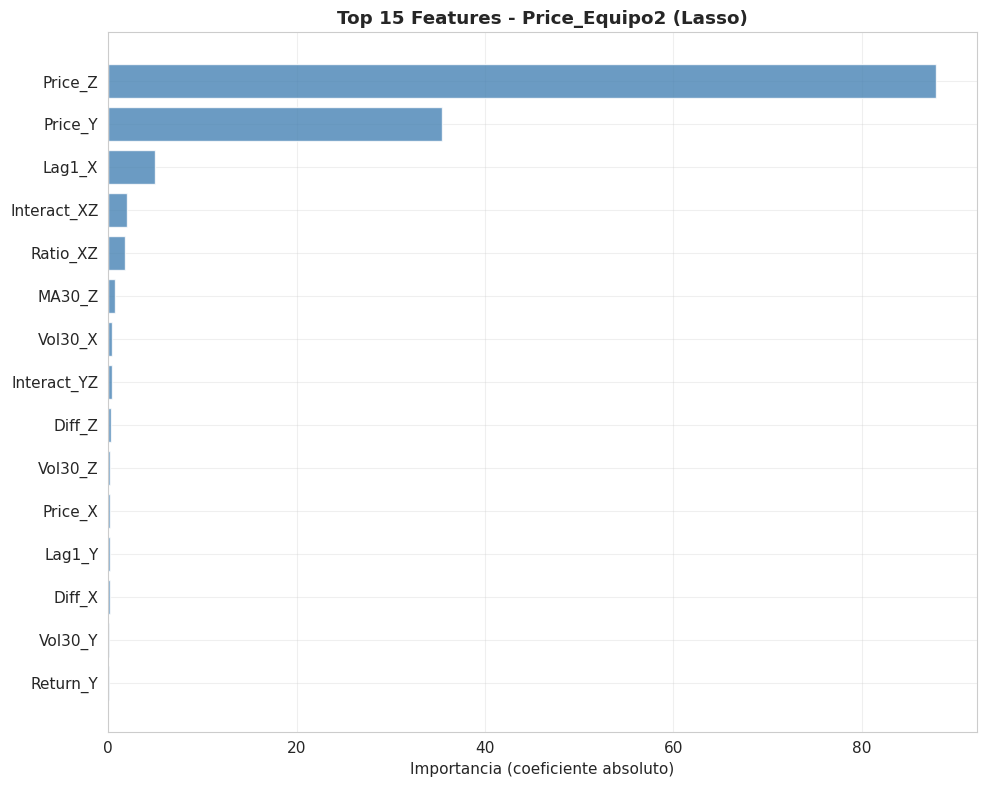

  Price_Z                  : 87.843154
  Price_Y                  : 35.394039
  Lag1_X                   : 4.915281
  Interact_XZ              : 1.993450
  Ratio_XZ                 : 1.817094
  MA30_Z                   : 0.745176
  Vol30_X                  : 0.367695
  Interact_YZ              : 0.352044
  Diff_Z                   : 0.264518
  Vol30_Z                  : 0.221630
  Price_X                  : 0.211621
  Lag1_Y                   : 0.188853
  Diff_X                   : 0.182844
  Vol30_Y                  : 0.081961
  Return_Y                 : 0.056855
Guardado en s3://consulting-dataknow-prueba-tecnica/eda_resultados/feature_importance.json


In [14]:
feature_importance_resultados = {}

for target in targets:
    mejor = mejores_modelos[target]
    modelo = mejor['modelo_obj']
    features = mejor['features']
    
    print(f'\n{"=" * 60}')
    print(f'  FEATURE IMPORTANCE - {target} ({mejor["modelo"]})')
    print(f'{"=" * 60}')
    
    if hasattr(modelo, 'feature_importances_'):
        importancias = modelo.feature_importances_
    elif hasattr(modelo, 'coef_'):
        importancias = np.abs(modelo.coef_)
    else:
        print('  No tiene feature importances directas.')
        continue
    
    fi = pd.DataFrame({'feature': features, 'importance': importancias})
    fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)
    top15 = fi.head(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(top15)), top15['importance'].values, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['feature'].values)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Features - {target} ({mejor["modelo"]})', fontweight='bold')
    ax.set_xlabel('Importancia (coeficiente absoluto)' if hasattr(modelo, 'coef_') else 'Importancia')
    plt.tight_layout()
    plt.show()
    
    for _, row in top15.iterrows():
        print(f'  {row["feature"]:25s}: {row["importance"]:.6f}')
    
    feature_importance_resultados[target] = {
        'modelo': mejor['modelo'],
        'importancias': fi.set_index('feature')['importance'].round(6).to_dict()
    }

guardar_json_s3(feature_importance_resultados, BUCKET, 'eda_resultados/feature_importance.json')

---
## 8. Validacion distribucional


  VALIDACION DISTRIBUCIONAL - Price_Equipo1
  KS Test: stat=0.032857, p=0.844607 (Misma dist.)
  Mann-Whitney: stat=244440.0000, p=0.941032 (Misma dist.)


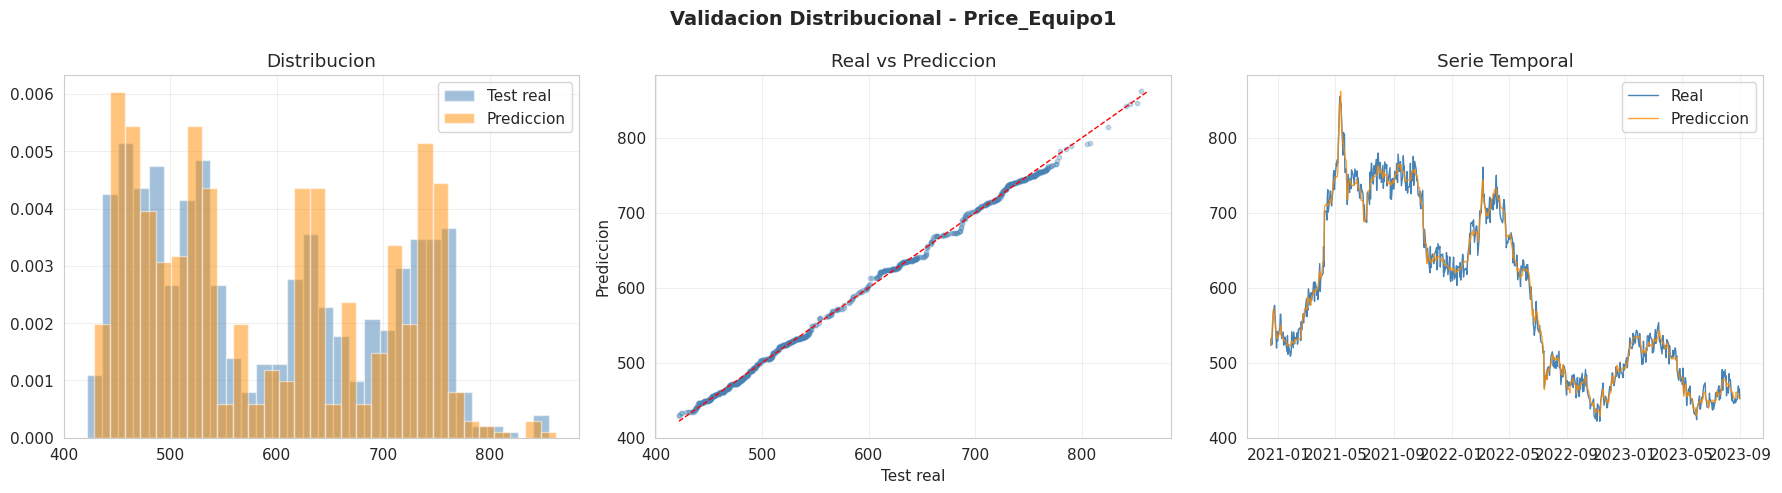


  VALIDACION DISTRIBUCIONAL - Price_Equipo2
  KS Test: stat=0.020000, p=0.999021 (Misma dist.)
  Mann-Whitney: stat=244597.0000, p=0.957560 (Misma dist.)


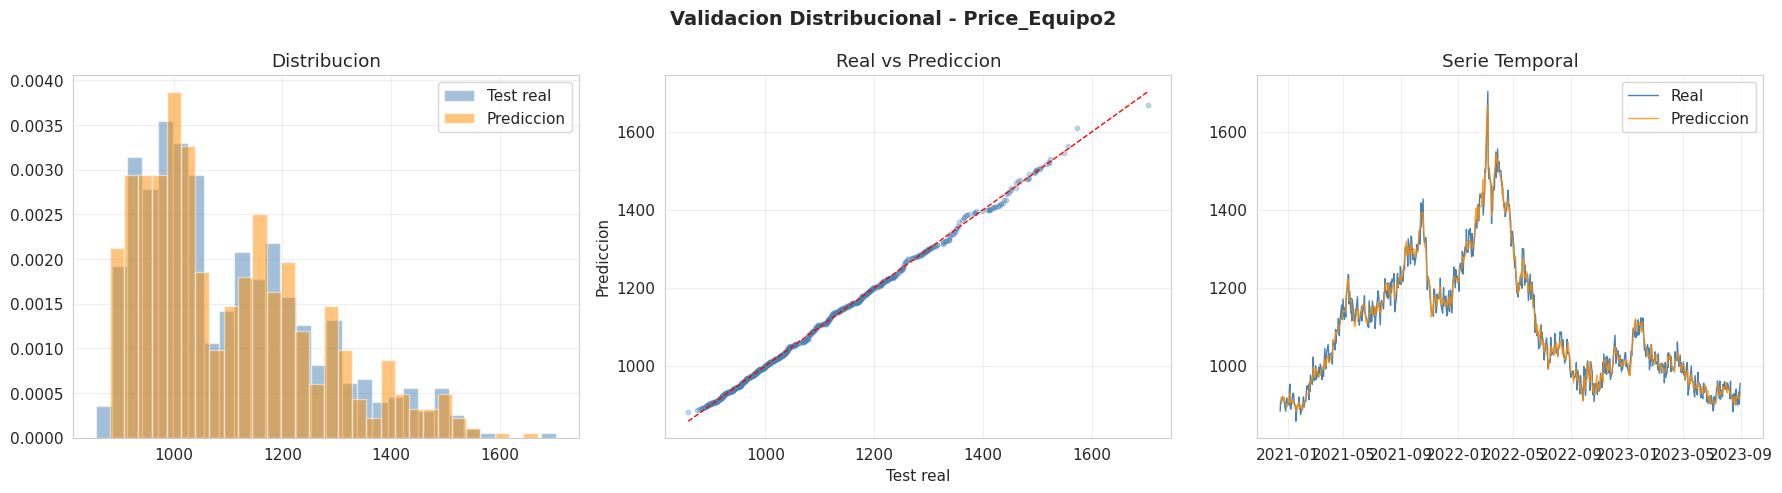

Guardado en s3://consulting-dataknow-prueba-tecnica/eda_resultados/validacion_distribucional.json


In [15]:
validacion_dist = {}

for target in targets:
    mejor = mejores_modelos[target]
    y_pred = mejor['y_pred_test']
    y_test = mejor['y_test']
    
    print(f'\n{"=" * 60}')
    print(f'  VALIDACION DISTRIBUCIONAL - {target}')
    print(f'{"=" * 60}')
    
    ks_stat, ks_p = stats.ks_2samp(y_pred, y_test)
    mw_stat, mw_p = stats.mannwhitneyu(y_pred, y_test, alternative='two-sided')
    
    print(f'  KS Test: stat={ks_stat:.6f}, p={ks_p:.6f} ({"Misma dist." if ks_p > 0.05 else "Dist. diferentes"})')
    print(f'  Mann-Whitney: stat={mw_stat:.4f}, p={mw_p:.6f} ({"Misma dist." if mw_p > 0.05 else "Dist. diferentes"})')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Validacion Distribucional - {target}', fontsize=14, fontweight='bold')
    
    axes[0].hist(y_test, bins=30, alpha=0.5, color='steelblue', label='Test real', density=True)
    axes[0].hist(y_pred, bins=30, alpha=0.5, color='darkorange', label='Prediccion', density=True)
    axes[0].legend()
    axes[0].set_title('Distribucion')
    
    axes[1].scatter(np.sort(y_test), np.sort(y_pred[:len(y_test)]), alpha=0.3, s=10, color='steelblue')
    lim_min = min(y_test.min(), y_pred.min())
    lim_max = max(y_test.max(), y_pred.max())
    axes[1].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1)
    axes[1].set_xlabel('Test real')
    axes[1].set_ylabel('Prediccion')
    axes[1].set_title('Real vs Prediccion')
    
    fechas_test = df['Date'].iloc[split_idx:].values
    axes[2].plot(fechas_test, y_test, linewidth=1, color='steelblue', label='Real')
    axes[2].plot(fechas_test, y_pred, linewidth=1, color='darkorange', label='Prediccion', alpha=0.8)
    axes[2].legend()
    axes[2].set_title('Serie Temporal')
    
    plt.tight_layout()
    plt.show()
    
    validacion_dist[target] = {
        'ks_statistic': round(ks_stat, 6), 'ks_p_value': round(ks_p, 6),
        'ks_resultado': 'Misma distribucion' if ks_p > 0.05 else 'Distribuciones diferentes',
        'mann_whitney_stat': round(mw_stat, 4), 'mann_whitney_p': round(mw_p, 6),
        'mann_whitney_resultado': 'Misma distribucion' if mw_p > 0.05 else 'Distribuciones diferentes'
    }

guardar_json_s3(validacion_dist, BUCKET, 'eda_resultados/validacion_distribucional.json')

---
## 9. Guardar modelos y resultados finales

In [16]:
import pickle

for target in targets:
    mejor = mejores_modelos[target]
    nombre_limpio = target.replace('Price_', '').lower()
    
    modelo_bytes = pickle.dumps(mejor['modelo_obj'])
    s3.put_object(Bucket=BUCKET, Key=f'modelos/mejor_modelo_{nombre_limpio}.pkl', Body=modelo_bytes)
    print(f'Modelo {mejor["modelo"]} para {target} guardado.')
    
    if mejor.get('scaler'):
        scaler_bytes = pickle.dumps(mejor['scaler'])
        s3.put_object(Bucket=BUCKET, Key=f'modelos/scaler_{nombre_limpio}.pkl', Body=scaler_bytes)
        print(f'Scaler para {target} guardado.')
    
    prophet_bytes = pickle.dumps(resultados_prophet[target]['modelo_obj'])
    s3.put_object(Bucket=BUCKET, Key=f'modelos/prophet_{nombre_limpio}.pkl', Body=prophet_bytes)
    print(f'Prophet para {target} guardado.')

guardar_json_s3({'features_con_interact': features_con_interact}, BUCKET, 'modelos/features_config.json')

# Prophet para agente
prophet_para_agente = {}
for target in targets:
    rp = resultados_prophet[target]
    prophet_para_agente[target] = {
        'train': rp['train'], 'test': rp['test'],
        'n_changepoints': rp['n_changepoints'],
        'changepoints': rp['changepoints'][:10],
        'regressors': ['Price_X', 'Price_Y', 'Price_Z'],
        'params': {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0}
    }
guardar_json_s3(prophet_para_agente, BUCKET, 'eda_resultados/prophet_resultados.json')

print('\nTodos los modelos y configuraciones guardados en S3.')

Modelo Lasso para Price_Equipo1 guardado.
Scaler para Price_Equipo1 guardado.
Prophet para Price_Equipo1 guardado.
Modelo Lasso para Price_Equipo2 guardado.
Scaler para Price_Equipo2 guardado.
Prophet para Price_Equipo2 guardado.
Guardado en s3://consulting-dataknow-prueba-tecnica/modelos/features_config.json
Guardado en s3://consulting-dataknow-prueba-tecnica/eda_resultados/prophet_resultados.json

Todos los modelos y configuraciones guardados en S3.


In [17]:
# Resumen final
print('\n' + '=' * 80)
print('RESUMEN FINAL DE MODELAMIENTO')
print('=' * 80)

resumen_modelamiento = {}

for target in targets:
    mejor = mejores_modelos[target]
    prophet = resultados_prophet[target]
    
    print(f'\n{target}:')
    print(f'  Mejor modelo ML: {mejor["modelo"]}')
    print(f'    R2: {mejor["test"]["r2"]:.6f}, RMSE: {mejor["test"]["rmse"]:.4f}, MAPE: {mejor["test"]["mape"]:.4f}%')
    if 'best_params' in mejor:
        print(f'    Params: {mejor["best_params"]}')
    print(f'  Prophet:')
    print(f'    R2: {prophet["test"]["r2"]:.6f}, RMSE: {prophet["test"]["rmse"]:.4f}, MAPE: {prophet["test"]["mape"]:.4f}%')
    
    resumen_modelamiento[target] = {
        'mejor_modelo_ml': {
            'nombre': mejor['modelo'],
            'metricas_test': mejor['test'],
            'best_params': mejor.get('best_params', {})
        },
        'prophet': {'metricas_test': prophet['test']}
    }

print('\n\nOBSERVACIONES:')
print('  - Los modelos lineales (Ridge, Lasso) generalizan significativamente mejor')
print('    que los tree-based (RF, XGBoost, GBM).')
print('  - Los tree-based muestran sobreajuste consistente: R2 train ~0.99 pero')
print('    R2 test cae a 0.5-0.7. Esto se debe a que el periodo de test')
print('    (post-COVID) tiene un regimen de precios diferente al train.')
print('  - La relacion entre materias primas y equipos es fundamentalmente lineal,')
print('    lo que explica por que los modelos lineales dominan.')
print('  - Agregar features derivadas no mejora significativamente sobre las')
print('    3 materias primas originales para los modelos lineales.')

guardar_json_s3(resumen_modelamiento, BUCKET, 'eda_resultados/resumen_modelamiento.json')

print('\nResultados guardados en S3.')


RESUMEN FINAL DE MODELAMIENTO

Price_Equipo1:
  Mejor modelo ML: Lasso
    R2: 0.991341, RMSE: 10.3081, MAPE: 1.5084%
    Params: {'alpha': 0.1}
  Prophet:
    R2: 0.991047, RMSE: 10.4818, MAPE: 1.5238%

Price_Equipo2:
  Mejor modelo ML: Lasso
    R2: 0.985174, RMSE: 19.3583, MAPE: 1.5071%
    Params: {'alpha': 0.1}
  Prophet:
    R2: 0.985125, RMSE: 19.3904, MAPE: 1.5149%


OBSERVACIONES:
  - Los modelos lineales (Ridge, Lasso) generalizan significativamente mejor
    que los tree-based (RF, XGBoost, GBM).
  - Los tree-based muestran sobreajuste consistente: R2 train ~0.99 pero
    R2 test cae a 0.5-0.7. Esto se debe a que el periodo de test
    (post-COVID) tiene un regimen de precios diferente al train.
  - La relacion entre materias primas y equipos es fundamentalmente lineal,
    lo que explica por que los modelos lineales dominan.
  - Agregar features derivadas no mejora significativamente sobre las
    3 materias primas originales para los modelos lineales.
Guardado en s3://con

## 10. JSON consolidado para el agente

In [ ]:
# JSON consolidado con toda la info del modelamiento para el agente
info_modelos = {}

for target in targets:
    mejor = mejores_modelos[target]
    rp = resultados_prophet[target]
    forecast_test = rp['forecast_test']
    
    # Cobertura IC Prophet
    dentro_ic = ((rp['y_test'] >= forecast_test['yhat_lower'].values) & 
                 (rp['y_test'] <= forecast_test['yhat_upper'].values)).mean() * 100
    
    info_modelos[target] = {
        'mejor_modelo_ml': {
            'nombre': mejor['modelo'],
            'metricas_train': mejor['train'],
            'metricas_test': mejor['test'],
            'best_params': mejor.get('best_params', {}),
            'features_usadas': mejor['features'],
            'n_features': len(mejor['features']),
            'usa_scaler': mejor.get('scaler') is not None
        },
        'prophet': {
            'metricas_train': rp['train'],
            'metricas_test': rp['test'],
            'n_changepoints': rp['n_changepoints'],
            'changepoints': rp['changepoints'][:10],
            'regressors': ['Price_X', 'Price_Y', 'Price_Z'],
            'params': {
                'changepoint_prior_scale': 0.05,
                'seasonality_prior_scale': 10.0,
                'interval_width': 0.95,
                'yearly_seasonality': True
            },
            'intervalo_confianza': {
                'nivel': '95%',
                'ancho_promedio_test': round(float((forecast_test['yhat_upper'] - forecast_test['yhat_lower']).mean()), 2),
                'cobertura_test': round(dentro_ic, 1)
            },
            'residuos': prophet_residuos_resultados.get(target, {})
        },
        'tree_based_descartados': {
            'razon': 'Sobreajuste consistente: R2 train ~0.99 pero R2 test 0.5-0.7 debido a cambio de regimen post-COVID',
            'modelos': ['RandomForest', 'GradientBoosting', 'XGBoost']
        },
        'observaciones': [
            'La relacion entre materias primas y equipos es fundamentalmente lineal',
            'Lasso y Prophet tienen desempeno practicamente identico',
            'Prophet se recomienda para proyeccion por los intervalos de confianza nativos',
            'Lasso se recomienda como modelo principal por simplicidad y ligera ventaja en metricas',
            'Las features derivadas no mejoran significativamente los modelos lineales'
        ],
        'split_temporal': {
            'train_inicio': str(df.iloc[0]['Date'].date()),
            'train_fin': str(df.iloc[split_idx-1]['Date'].date()),
            'test_inicio': str(df.iloc[split_idx]['Date'].date()),
            'test_fin': str(df.iloc[-1]['Date'].date()),
            'train_n': split_idx,
            'test_n': len(df) - split_idx
        }
    }

guardar_json_s3(info_modelos, BUCKET, 'eda_resultados/info_modelos_completa.json')
print('JSON consolidado guardado para el agente.')